# CosmoCalc: Python Calculator for Cosmogenic Nuclide Exposure Ages

**Authors:** Michal Ben-Israel  
**Based on:** Balco et al. (2008) CRONUS-Earth calculator v3  
**License:** GNU GPL v2  

## Overview
Python implementation of 10Be (and 26Al) surface exposure age and denudation rate 
calculator. Translated and updated from the MATLAB-based CRONUS-Earth framework 
(Balco et al., 2008) with the following updates:
- LSDn scaling scheme (Lifton et al., 2014)
- Updated production rates (Borchers et al., 2016)
- Updated muon production (Balco, 2017)

## References
- Balco et al. (2008) Quaternary Geochronology 3, 174-195
- Lifton et al. (2014) EPSL 386, 149-160
- Borchers et al. (2016) Quaternary Geochronology 31, 188-198
- Balco (2017) Quaternary Geochronology 39, 150-173

## 1. Load data files

In [28]:
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator, interp1d
from scipy.integrate import cumulative_trapezoid

In [29]:
# ================================================
# CONSTANTS
# Borchers et al. (2016) Table 7
# SLHL spallation production rates (atoms/g quartz/yr)
# ================================================

# 10Be production rates
P10_St   = 4.01   # Stone (2000)
P10_Lm   = 4.00   # Lal/Stone paleomagnetic
P10_LSDn = 3.92   # Lifton-Sato-Dunai (preferred, v3 default)

# 26Al production rates
P26_St   = 27.93
P26_Lm   = 27.93
P26_LSDn = 28.54

# Decay constants (yr-1)
l10 = 4.9975e-7   # 10Be, half-life 1.387 Ma (Korschinek et al. 2010)
l26 = 9.83e-7     # 26Al, half-life 0.705 Ma (Nishiizumi 2004)

# Attenuation lengths (g/cm2)
Lsp  = 160.0      # spallation (Gosse & Phillips 2001)
Lmu  = 1500.0     # muons

## 2. Load data files

In [ ]:
# Load data files
ncep      = sio.loadmat('../data/NCEP2.mat',            squeeze_me=True, struct_as_record=False)
pmag07    = sio.loadmat('../data/PMag_Mar07.mat',        squeeze_me=True, struct_as_record=False)
pmag12    = sio.loadmat('../data/Pmag_Sep12.mat',        squeeze_me=True, struct_as_record=False)
lsd       = sio.loadmat('../data/consts_LSD.mat',        squeeze_me=True, struct_as_record=False)
consts_v23 = sio.loadmat('../data/al_be_consts_v23.mat', squeeze_me=True, struct_as_record=False)


## 3. Atmosphere
Converts sample elevation to atmospheric pressure using the NCEP reanalysis 
gridded sea-level pressure and temperature data (NCEPatm_2.m equivalent).

In [19]:
def ncep_pressure(lat, lon, elv):
    """
    Atmospheric pressure from elevation using NCEP reanalysis.
    Equivalent to NCEPatm_2.m (Balco v2.3).

    Inputs:
        lat : latitude (degrees N)
        lon : longitude (degrees E, 0-360)
        elv : elevation (m)
    Returns:
        pressure : atmospheric pressure (hPa)
    """
    NCEPlat   = ncep['NCEPlat']
    NCEPlon   = ncep['NCEPlon']
    meanslp   = ncep['meanslp']
    meant1000 = ncep['meant1000']

    interp_slp = RegularGridInterpolator((NCEPlat, NCEPlon), meanslp)
    interp_T   = RegularGridInterpolator((NCEPlat, NCEPlon), meant1000)

    slp = interp_slp([[lat, lon]])[0]
    T   = interp_T([[lat, lon]])[0] + 273.15

    gmr  = -0.03417
    dtdz =  0.0065

    pressure = slp * np.exp((gmr / dtdz) * (np.log(T) - np.log(T - elv * dtdz)))
    return pressure

# Test
print(f"Pressure at 37N, 240E, 3000m: {ncep_pressure(37.0, 240.0, 3000.0):.2f} hPa")

## 4. Load Sample Data
Reads sample input from CosmoCalc_in.xlsx.
Converts longitude to 0-360 for NCEP interpolation.
Applies AMS standard normalization to 07KNSTD.

In [40]:
def load_samples(filepath, sheet='CosmoCalc_in'):
    """
    Load sample data from CosmoCalc input spreadsheet.
    
    Inputs:
        filepath : path to Excel file
        sheet    : sheet name (default 'CosmoCalc_in')
    Returns:
        df : DataFrame with all sample data, 
             lon converted to 0-360,
             N10/delN10 normalized to 07KNSTD
    """
    df = pd.read_excel(filepath, sheet_name=sheet)
    
    # Convert longitude to 0-360 for NCEP interpolation
    df['lon_360'] = df['lon'] % 360
    
    # AMS standard normalization to 07KNSTD
    std_factors = {
        '07KNSTD'   : 1.0000,
        'KNSTD'     : 0.9996,
        'NIST_27900': 0.9785,
        'NIST_30000': 1.0000,
        'LLNL31000' : 1.0881,
        'LLNL10000' : 0.3511,
        'UVM-A'     : 0.0502,  # Corbett et al. 2019
        'BEST433'   : 0.9124,
        'S555'      : 0.9124,
    }
    
    df['std_factor'] = df['std'].map(std_factors)
    df['N10_norm']    = df['N10']    * df['std_factor']
    df['delN10_norm'] = df['delN10'] * df['std_factor']

## 5. Snow data (SNOTEL)
Snow shielding calculations based on Bason on Gosse & Phillips (2001)
Source: NRCS SNOTEL North Lake station (NTH), CA
Elevation: 9280 ft | Period of record: 1930-2026
Monthly SWE (snow water equivalent, cm)

In [41]:
df_snow = pd.read_csv('../data/NTH_snow.csv', skiprows=62, header=[0,1])

swe_cols = [('Jan', 'Snow Water Equivalent (in) Start of Month Values'),
            ('Feb', 'Snow Water Equivalent (in) Start of Month Values'),
            ('Mar', 'Snow Water Equivalent (in) Start of Month Values'),
            ('Apr', 'Snow Water Equivalent (in) Start of Month Values'),
            ('May', 'Snow Water Equivalent (in) Start of Month Values'),
            ('Jun', 'Snow Water Equivalent (in) Start of Month Values')]

swe_cm = np.zeros(12)
for i, col in enumerate(swe_cols):
    swe = pd.to_numeric(df_snow[col], errors='coerce')
    valid = swe.notna() & (swe > 0)
    if valid.sum() > 0:
        swe_cm[i] = swe[valid].mean() * 2.54

## 6. Cover Corrections
Calculates the scaling factor for sample thickness and surface cover 
(soil, till). Equivalent to the thickness correction in Balco v2.3,
extended to include multiple cover layers.

In [42]:
def cover_correction(rho_rock, thickness,
                     depth_soil=0.0, rho_soil=1.6,
                     depth_till=0.0, rho_till=1.9,
                     swe_monthly=None,
                     L=160.0):
    """
    Thickness and cover scaling factor for n samples.
    Vectorized — accepts scalars or arrays of length n.

    Inputs:
        rho_rock    : rock density (g/cm3), scalar or array
        thickness   : sample thickness (cm), scalar or array
        depth_soil  : soil depth (cm), scalar or array, default 0
        rho_soil    : soil density (g/cm3), default 1.6
        depth_till  : till depth (cm), scalar or array, default 0
        rho_till    : till density (g/cm3), default 1.9
        swe_monthly : array (12,) of monthly snow water equivalent (cm)
                      from SNOTEL or similar. None = no snow correction.
        L           : spallation attenuation length (g/cm2), default 160

    Returns:
        SF_thickness : rock+soil+till scaling factor, array length n
        SF_snow      : snow shielding factor, array length n
    """
    rho_rock   = np.atleast_1d(np.array(rho_rock,   dtype=float))
    thickness  = np.atleast_1d(np.array(thickness,  dtype=float))
    depth_soil = np.atleast_1d(np.array(depth_soil, dtype=float))
    depth_till = np.atleast_1d(np.array(depth_till, dtype=float))
    n = len(rho_rock)

    # Solid cover
    total_solid  = (rho_rock * thickness +
                    rho_soil * depth_soil +
                    rho_till * depth_till)
    SF_thickness = (L / total_solid) * (1 - np.exp(-total_solid / L))

    # Snow shielding via SWE (Gosse & Phillips 2001, Schildgen et al. 2005)
    if swe_monthly is None:
        SF_snow = np.ones(n)
    else:
        swe = np.array(swe_monthly, dtype=float)
        SF_snow = np.full(n, np.mean(np.exp(-swe / L)))

    return SF_thickness, SF_snow

## 7. Stone 2000 Scaling (St)
Time-independent scaling scheme after Lal (1991) as reformulated by Stone (2000).
Scales spallation production rate as a function of atmospheric pressure and latitude.
Equivalent to stone2000.m from Balco v2.3.
Reference: Stone (2000) JGR 105, 23753-23759.

In [43]:
def stone2000(lat, pressure, Fsp=1.0):
    """
    Stone (2000) scaling factor for cosmogenic nuclide production.
    Exact translation of stone2000.m from Balco v2.3.
    
    Inputs:
        lat      : latitude (degrees, scalar or array)
        pressure : atmospheric pressure (hPa, scalar or array)
        Fsp      : fraction of production by spallation (default 1.0)
                   Use 0.978 for 10Be, 0.974 for 26Al (Stone 2000 defaults)
    Returns:
        SF : scaling factor array
    """
    lat      = np.abs(np.atleast_1d(np.array(lat,      dtype=float)))
    pressure = np.atleast_1d(np.array(pressure, dtype=float))
    
    assert len(lat) == len(pressure), "lat and pressure must be same length"

    # Table 1 coefficients from Stone (2000)
    a = np.array([31.8518, 34.3699, 40.3153, 42.0983, 56.7733, 69.0720, 71.8733])
    b = np.array([250.3193, 258.4759, 308.9894, 512.6857, 649.1343, 832.4566, 863.1927])
    c = np.array([-0.083393, -0.089807, -0.106248, -0.120551, -0.160859, -0.199252, -0.207069])
    d = np.array([7.4260e-5, 7.9457e-5, 9.4508e-5, 1.1752e-4, 1.5463e-4, 1.9391e-4, 2.0127e-4])
    e = np.array([-2.2397e-8, -2.3697e-8, -2.8234e-8, -3.8809e-8, -5.0330e-8, -6.3653e-8, -6.6043e-8])
    ilats = np.array([0, 10, 20, 30, 40, 50, 60])

    # Clip latitude at 60 (same as Balco)
    lat = np.clip(lat, 0, 60)

    # Muon latitude factors (Table 1, Mx,1013.25)
    mk = np.array([0.587, 0.600, 0.678, 0.833, 0.933, 1.000, 1.000])

    S = np.zeros(len(lat))
    M = np.zeros(len(lat))

    for i in range(len(lat)):
        P = pressure[i]
        
        # Evaluate spallation polynomial at all 7 index latitudes
        # then interpolate to sample latitude -- exactly as Balco does it
        Slats = a + b*np.exp(-P/150.0) + c*P + d*P**2 + e*P**3
        S[i] = interp1d(ilats, Slats, kind='linear')(lat[i])

        # Muon scaling (Stone 2000 Eq. 3)
        Mlats = mk * np.exp((1013.25 - P) / 242.0)
        M[i] = interp1d(ilats, Mlats, kind='linear')(lat[i])

    # Combine spallation and muon terms
    SF = Fsp * S + (1 - Fsp) * M

    return SF

In [45]:
# Apply atmosphere, cover, and snow corrections to all samples
pressure   = np.array([ncep_pressure(row.lat, row.lon_360, row.elv) 
                       for _, row in df.iterrows()])

SF_thick, SF_snow = cover_correction(
    rho_rock   = df['rho_smp'].values,
    thickness  = df['thickness'].values,
    depth_soil = df['cover'].values,
    rho_soil   = df['rho_cover'].values,
    swe_monthly = swe_cm
)

SF_stone = stone2000(np.abs(df['lat'].values), pressure)

## 9. Exposure Age Solver — Stone 2000 (St)
Simple exposure age calculation using the time-independent St scaling scheme.
Closed-form solution — no forward integration needed.
Zero erosion assumed (surface samples).

In [48]:
def age_st(N10, delN10, P_total, l10=l10, delP_frac=0.35/4.01):
    """
    Exposure age and uncertainties from 10Be using Stone 2000 (St).
    Closed-form solution, zero erosion.
    
    Inputs:
        N10       : 10Be concentration (atoms/g)
        delN10    : 1σ uncertainty on N10 (atoms/g)
        P_total   : total production rate at site (atoms/g/yr)
        l10       : decay constant (yr-1)
        delP_frac : fractional uncertainty on production rate
    Returns:
        t         : exposure age (yr)
        delt_int  : internal uncertainty - measurement only (yr)
        delt_ext  : external uncertainty - production rate only (yr)
        delt_tot  : total uncertainty - combined in quadrature (yr)
    """
    if N10 >= P_total / l10:
        return np.inf, np.inf, np.inf, np.inf

    t = (-1/l10) * np.log(1 - (N10 * l10 / P_total))

    # Partial derivatives
    dtdN = 1.0 / (P_total - N10 * l10)
    dtdP = -t / P_total

    # Three uncertainty components
    delt_int = np.abs(dtdN) * delN10
    delt_ext = np.abs(dtdP) * P_total * delP_frac
    delt_tot = np.sqrt(delt_int**2 + delt_ext**2)

    return t, delt_int, delt_ext, delt_tot


# Calculate St ages with all uncertainties
print(f"{'Sample':<20} {'Age (ka)':>9} {'±int':>7} {'±ext':>7} {'±tot':>7}")
print("-"*55)

for i, row in df.iterrows():
    P_total = P10_St * SF_thick[i] * SF_snow[i] * SF_stone[i] * row.shieldcorr
    t, dint, dext, dtot = age_st(row.N10_norm, row.delN10_norm, P_total)
    print(f"{row['sample']:<20} {t/1000:>9.2f} "
          f"{dint/1000:>7.2f} {dext/1000:>7.2f} {dtot/1000:>7.2f}")

Sample                Age (ka)    ±int    ±ext    ±tot
-------------------------------------------------------
22-MBI-008-SBL1b         14.48    0.27    1.26    1.29
22-MBI-010-SBL2          15.39    0.29    1.34    1.38
22-MBI-020-SBL5b         15.43    0.42    1.35    1.41
22-MBI-045-SBL9b         12.69    0.24    1.11    1.13
23-MBI-009-SBL11         14.59    0.24    1.27    1.30
23-MBI-010-SBL12         14.12    0.24    1.23    1.26
22-MBI-061-SHL1          15.45    0.30    1.35    1.38
22-MBI-069-SHL2          17.17    0.32    1.50    1.53
22-MBI-076-SHL3          14.23    0.26    1.24    1.27
22-MBI-084-SHL4          15.27    0.25    1.33    1.36
22-MBI-086-SHL6          15.85    0.29    1.38    1.41


In [54]:
# Build the time vector
tv = np.concatenate([
    np.arange(0, 6500+500, 500),      # 0-6500 in 500yr steps
    np.array([6900]),                   # one extra point
    np.arange(7500, 11500+1000, 1000), # 7500-11500 in 1000yr steps
    np.arange(12000, 800000+1000, 1000), # 12000-800000 in 1000yr steps
    np.logspace(np.log10(810000), 7, 200) # log-spaced to 10Ma
])

## 10. Lm Scaling (Paleomagnetically Corrected Lal/Stone)
Time-dependent scaling scheme using paleomagnetically corrected cutoff rigidity.
Equivalent to stone2000Rcsp.m from Balco v2.3.
Requires: PMag_Mar07.mat for Rc(t) time series.

In [55]:
def stone2000Rcsp(pressure, Rc):
    """
    Stone 2000 scaling using cutoff rigidity Rc instead of latitude.
    Equivalent to stone2000Rcsp.m from Balco v2.3.
    Time-dependent version for Lm scaling.
    
    Inputs:
        pressure : atmospheric pressure (hPa), scalar
        Rc       : cutoff rigidity (GV), scalar or array of time steps
    Returns:
        SF : scaling factor array (same length as Rc)
    """
    # Rc to latitude conversion (dipole approximation)
    # Rc = 14.9 * cos^4(lambda) → lambda = arccos((Rc/14.9)^0.25)
    Rc   = np.atleast_1d(np.array(Rc, dtype=float))
    
    # Clip Rc to valid range
    Rc = np.clip(Rc, 0, 14.9)
    
    # Convert Rc to effective latitude
    lat_eff = np.degrees(np.arccos(np.clip((Rc / 14.9)**0.25, 0, 1)))
    lat_eff = np.clip(lat_eff, 0, 60)

    # Stone 2000 coefficients
    a = np.array([31.8518, 34.3699, 40.3153, 42.0983, 56.7733, 69.0720, 71.8733])
    b = np.array([250.3193, 258.4759, 308.9894, 512.6857, 649.1343, 832.4566, 863.1927])
    c = np.array([-0.083393, -0.089807, -0.106248, -0.120551, -0.160859, -0.199252, -0.207069])
    d = np.array([7.4260e-5, 7.9457e-5, 9.4508e-5, 1.1752e-4, 1.5463e-4, 1.9391e-4, 2.0127e-4])
    e = np.array([-2.2397e-8, -2.3697e-8, -2.8234e-8, -3.8809e-8, -5.0330e-8, -6.3653e-8, -6.6043e-8])
    ilats = np.array([0, 10, 20, 30, 40, 50, 60])

    SF = np.zeros(len(Rc))
    for i in range(len(Rc)):
        Slats = a + b*np.exp(-pressure/150.0) + c*pressure + d*pressure**2 + e*pressure**3
        SF[i] = interp1d(ilats, Slats, kind='linear')(lat_eff[i])

    return SF

In [60]:
from scipy.interpolate import RegularGridInterpolator

def angdist_py(lat1, lon1, lat2, lon2):
    """Angular distance between two points on a sphere (degrees)."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return np.degrees(2 * np.arcsin(np.sqrt(a)))


def compute_Rc_lm(lat, lon, tv, pmag):
    """
    Compute cutoff rigidity time series Rc(t) for Lm scaling.
    Exact translation of LmRc construction in Balco's cosmo_engine.m
    
    Steps 1-15  (0-6900 yr): KC pole positions + MM0_KCL
    Steps 16+   (7500+ yr) : axial dipole + MM0
    """
    MM0_KCL    = pmag['MM0_KCL']
    lat_pp_KCL = pmag['lat_pp_KCL']
    lon_pp_KCL = pmag['lon_pp_KCL']
    t_M        = pmag['t_M']
    MM0        = pmag['MM0']

    lat_rd = np.radians(lat)
    LmRc   = np.zeros(len(tv))

    # Segment 1: steps 1-15 (tv[0:15] = 0 to 6900 yr)
    for i in range(15):
        lm_lat    = abs(90 - angdist_py(lat, lon,
                                         lat_pp_KCL[i],
                                         lon_pp_KCL[i]))
        lm_lat_rd = np.radians(lm_lat)
        LmRc[i]   = 14.9 * MM0_KCL[i] * (np.cos(abs(lm_lat_rd))**4)

    # Segment 2: steps 16+ (tv[15:] = 7500 yr onward)
    t_M_ext  = np.append(t_M[:-1], t_M[-2] + 1000)
    MM0_ext  = np.append(MM0[:-1], MM0[-2])

    tv_rest    = tv[15:]
    tv_clipped = np.clip(tv_rest, t_M_ext[0], t_M_ext[-1])
    MM0_interp = interp1d(t_M_ext, MM0_ext,
                          kind='linear',
                          bounds_error=False,
                          fill_value=(MM0_ext[0], MM0_ext[-1]))(tv_clipped)

    LmRc[15:] = 14.9 * MM0_interp * (np.cos(abs(lat_rd))**4)

    return LmRc

Rc at t=0:    4.586 GV
Rc at t=6900: 3.705 GV
Rc at t=7500: 5.470 GV
Rc at t=15ka: 4.825 GV
Rc range: 0.57 - 8.05 GV


/var/folders/g2/lhnhcz5d3qv1043ybgndckm00000gp/T/ipykernel_57127/1487070834.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


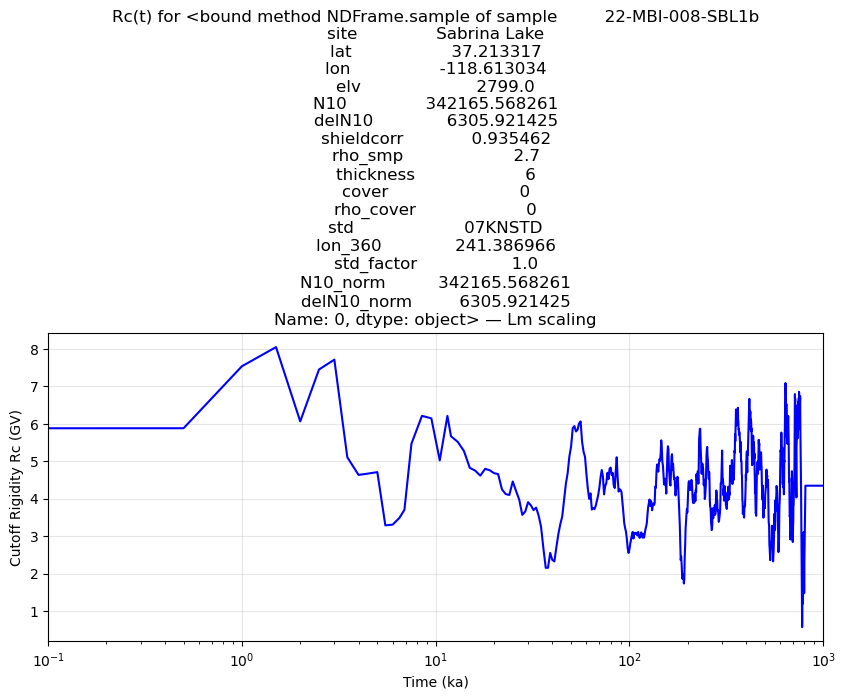

In [62]:
# Test on first sample
LmRc_test = compute_Rc_lm(row0.lat, row0.lon_360, tv, pmag07)

print(f"Rc at t=0:    {LmRc_test[0]:.3f} GV")
print(f"Rc at t=6900: {LmRc_test[14]:.3f} GV")
print(f"Rc at t=7500: {LmRc_test[15]:.3f} GV")
print(f"Rc at t=15ka: {LmRc_test[np.argmin(abs(tv-15000))]:.3f} GV")
print(f"Rc range: {LmRc_test.min():.2f} - {LmRc_test.max():.2f} GV")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(tv/1000, LmRc_test, 'b-', lw=1.5)
ax.set_xlabel('Time (ka)')
ax.set_ylabel('Cutoff Rigidity Rc (GV)')
ax.set_title(f'Rc(t) for {row0.sample} — Lm scaling')
ax.set_xscale('log')
ax.set_xlim([0.1, 1000])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
# Diagnose each segment separately
print("TTRc grid info:")
print(f"  lat_Rc: {pmag07['lat_Rc'].min():.1f} to {pmag07['lat_Rc'].max():.1f}, shape {pmag07['lat_Rc'].shape}")
print(f"  lon_Rc: {pmag07['lon_Rc'].min():.1f} to {pmag07['lon_Rc'].max():.1f}, shape {pmag07['lon_Rc'].shape}")
print(f"  t_Rc:   {pmag07['t_Rc']}")
print(f"  TTRc shape: {pmag07['TTRc'].shape}")

print(f"\nSample location: lat={row0.lat:.2f}, lon_360={row0.lon_360:.2f}")

# Check what TTRc gives at t=0 for our sample
interp_test = RegularGridInterpolator(
    (pmag07['lat_Rc'], pmag07['lon_Rc'], pmag07['t_Rc']), 
    pmag07['TTRc'],
    method='linear', bounds_error=False, fill_value=None
)
for t_test in [0, 500, 1000, 3000, 6500, 6900]:
    val = interp_test([[row0.lat, row0.lon_360, t_test]])[0]
    print(f"  TTRc at t={t_test}: {val:.3f} GV")

TTRc grid info:
  lat_Rc: -90.0 to 90.0, shape (37,)
  lon_Rc: 0.0 to 360.0, shape (25,)
  t_Rc:   [   0  500 1000 1500 2000 2500 3000 3500 4000 4500 5000 5500 6000 6500
 6900]
  TTRc shape: (37, 25, 15)

Sample location: lat=37.21, lon_360=241.39
  TTRc at t=0: 4.592 GV
  TTRc at t=500: 6.675 GV
  TTRc at t=1000: 8.305 GV
  TTRc at t=3000: 10.129 GV
  TTRc at t=6500: 4.049 GV
  TTRc at t=6900: 3.842 GV


In [64]:
print(f"Rc at t=0:    {LmRc_test[0]:.3f} GV")
print(f"Rc at t=6900: {LmRc_test[14]:.3f} GV")
print(f"Rc at t=7500: {LmRc_test[15]:.3f} GV")
print(f"Rc at t=15ka: {LmRc_test[np.argmin(abs(tv-15000))]:.3f} GV")
print(f"Rc range: {LmRc_test.min():.2f} - {LmRc_test.max():.2f} GV")

Rc at t=0:    4.586 GV
Rc at t=6900: 3.705 GV
Rc at t=7500: 5.470 GV
Rc at t=15ka: 4.825 GV
Rc range: 0.57 - 8.05 GV
